In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Load text file ---
# Replace with your actual file name
file_path = "../bin/full_cell_output.txt"

with open(file_path, 'r') as f:
    lines = f.readlines()

# --- Step 2: Parse each line using regex ---
data = []
pattern = re.compile(
    r"timestep:\s*(\d+).*?Anode current\s*=\s*([-eE0-9.]+),\s*Cathode current\s*=\s*([-eE0-9.]+),.*?Target Current\s*=\s*([-eE0-9.]+)"
)

for line in lines:
    match = pattern.search(line)
    if match:
        timestep = int(match.group(1))
        anode = abs(float(match.group(2)))  # absolute value
        cathode = float(match.group(3))
        target = float(match.group(4))
        data.append((timestep, anode, cathode, target))

# --- Step 3: Convert to DataFrame ---
df = pd.DataFrame(data, columns=["Timestep", "Anode", "Cathode", "Target"])

df = df[df["Timestep"] != 0] # Remove timestep 0


# --- Step 4: Plot ---
plt.figure(figsize=(10,6))
plt.plot(df["Timestep"], df["Anode"], label="Anode current", linewidth=2)
plt.plot(df["Timestep"], df["Cathode"], label="Cathode current", linewidth=2)
plt.plot(df["Timestep"], df["Target"], '--', label="Target current", linewidth=2)

plt.xlabel("Time step")
plt.ylabel("Current")
plt.title("Full-Cell Currents vs Time Step")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


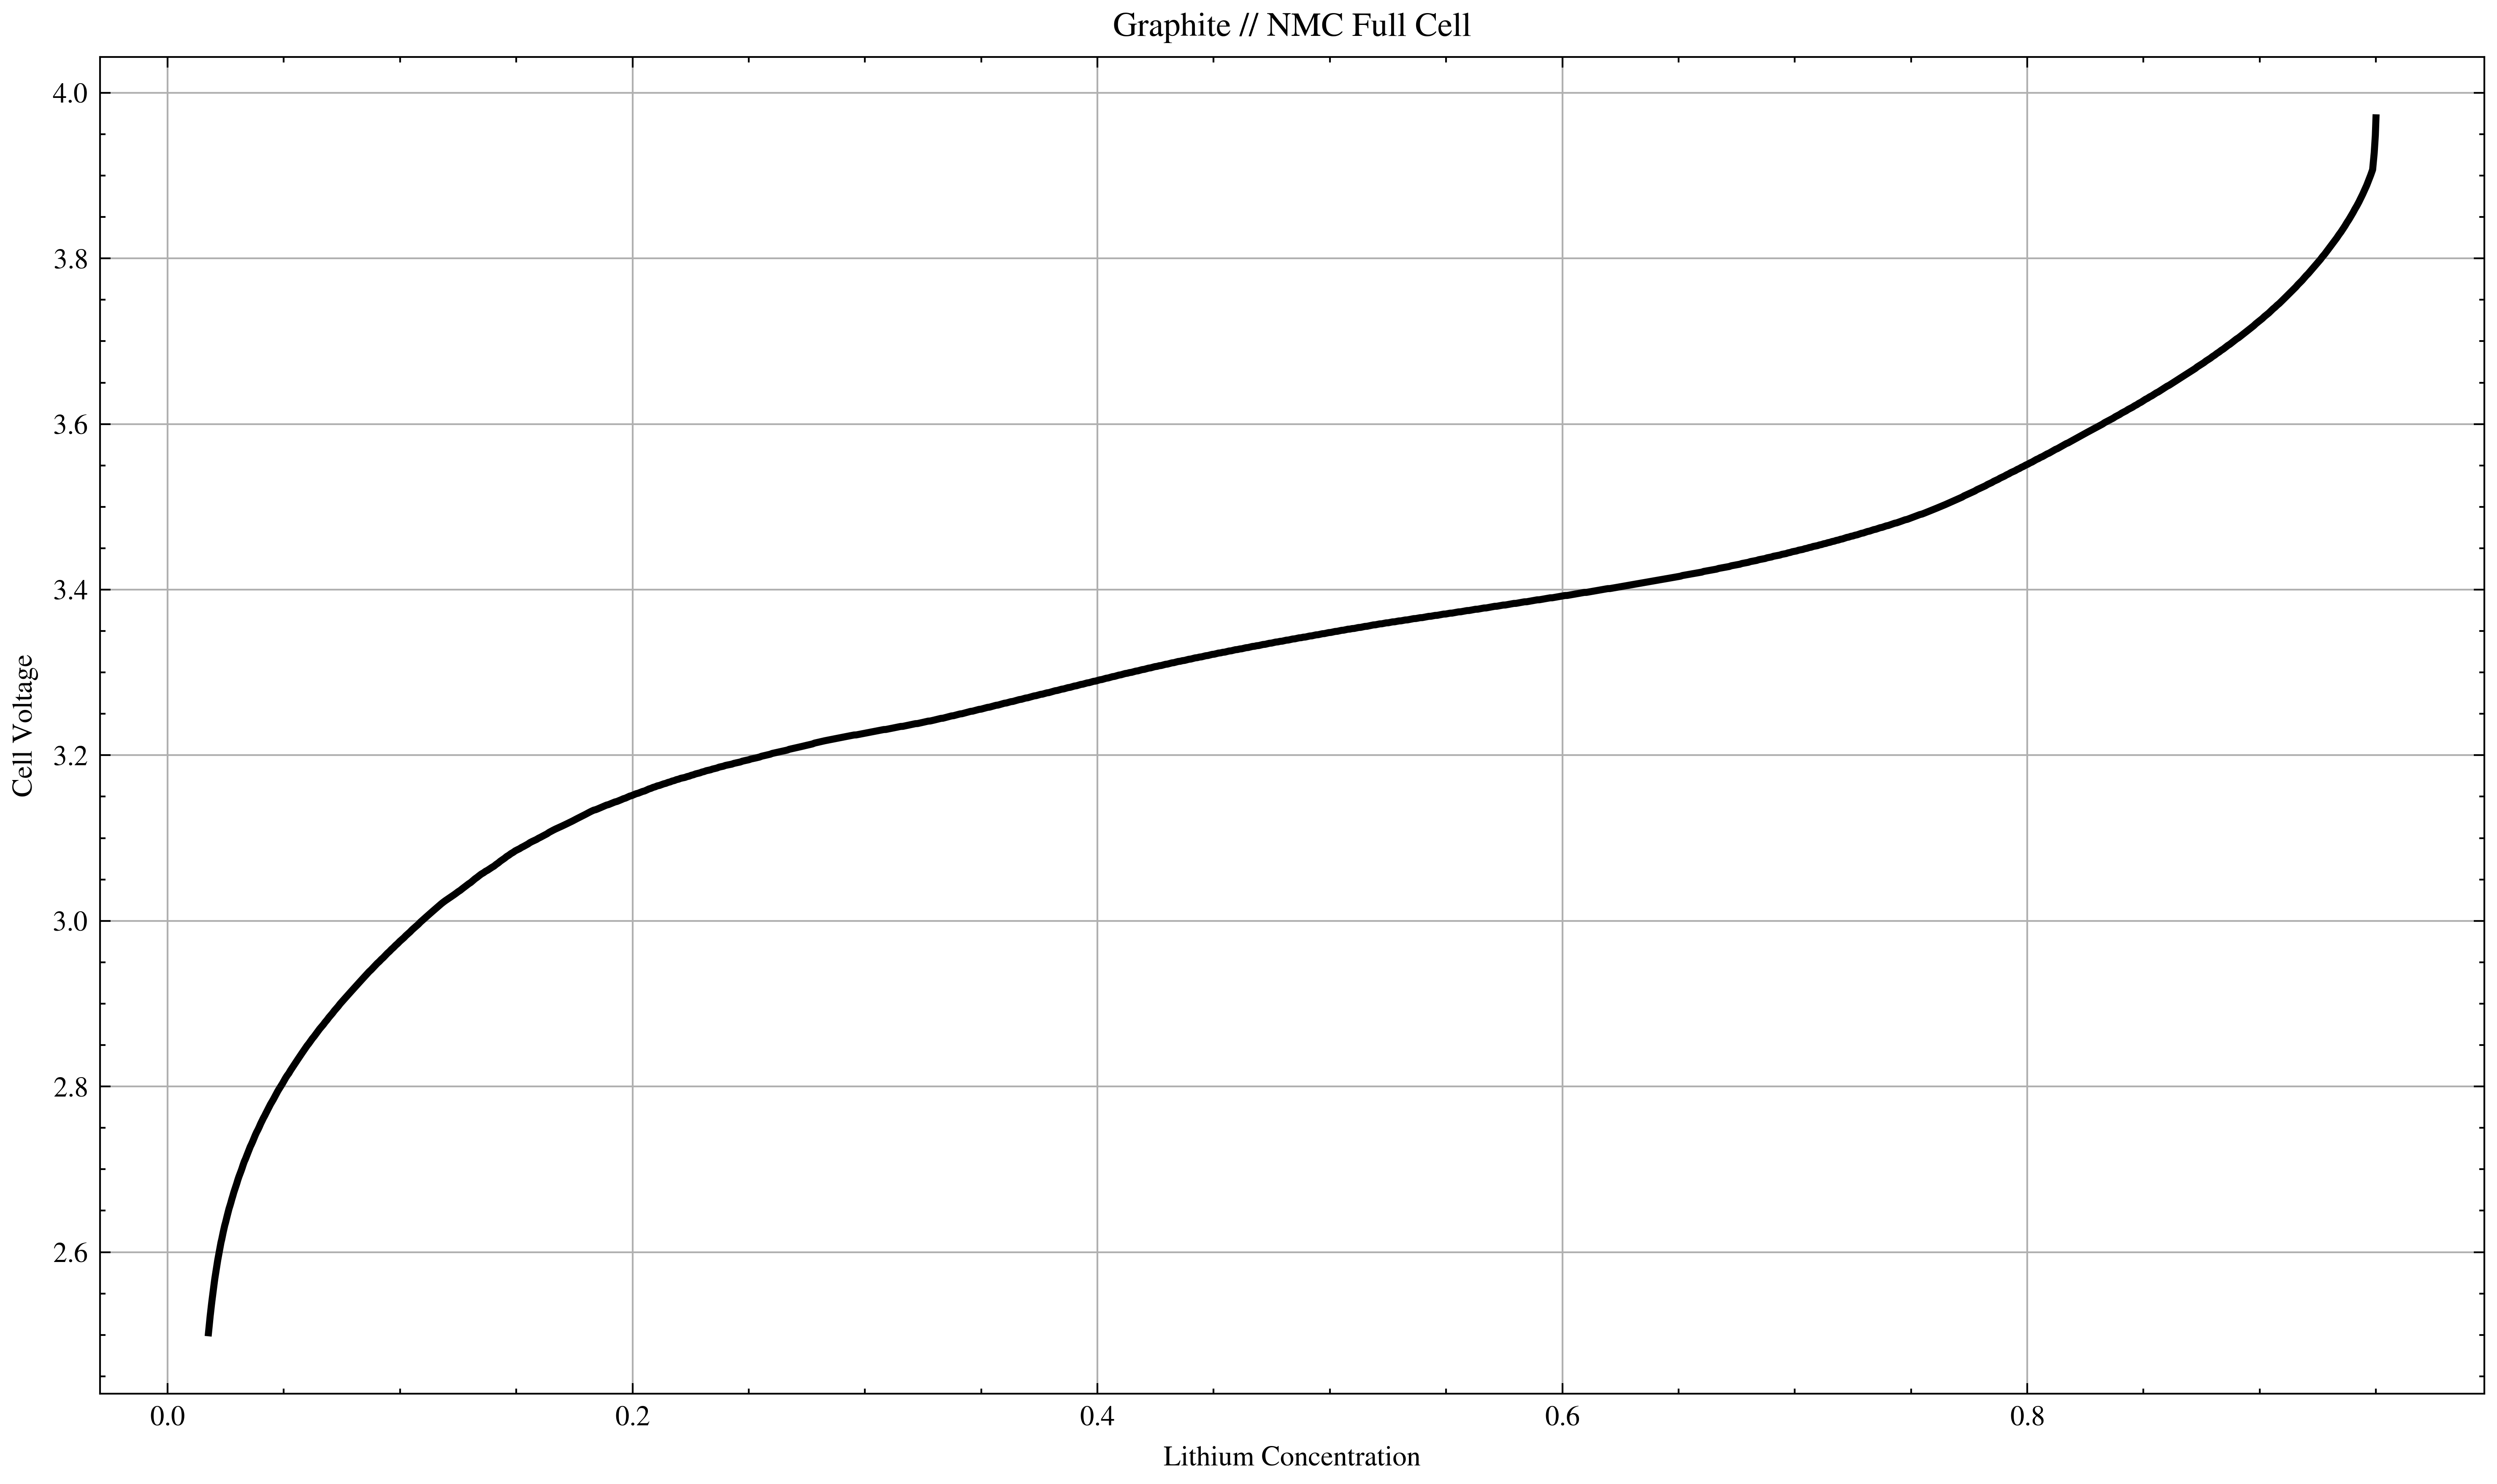

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Load text file ---
# Replace with your actual file name
file_path = "../bin/full_cell_output_03.txt"

with open(file_path, 'r') as f:
    lines = f.readlines()

# --- Step 2: Parse each line using regex ---
data = []
pattern = re.compile(
    r"XfrA\s*=\s*([-eE0-9.]+),.*?VCell\s*=\s*([-eE0-9.]+)"
)

for line in lines:
    match = pattern.search(line)
    if match:
        XfrA = float(match.group(1))
        vcell = abs(float(match.group(2)))  # absolute value
        data.append((XfrA, vcell))

# --- Step 3: Convert to DataFrame ---
df = pd.DataFrame(data, columns=["XfrA", "VCell"])

# df = df[df["XfrA"] != 0.3] # Remove timestep 0


# --- Step 4: Plot ---
with plt.style.context(['science', 'ieee', 'no-latex']):
    plt.figure(figsize=(10,6))
    plt.plot(df["XfrA"], df["VCell"], label="VCell", linewidth=2)
    # plt.gca().invert_xaxis() # Invert x-axis to show higher XfrA on the left

    plt.xlabel("Lithium Concentration", fontsize=12)
    plt.ylabel("Cell Voltage", fontsize=12)
    plt.title("Graphite // NMC Full Cell", fontsize=14)
    # plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [2]:
# !sudo apt-get install dvipng texlive-latex-extra texlive-fonts-recommended texlive-latex-recommended cm-super

pip install SciencePlots

SyntaxError: invalid syntax (1120833066.py, line 3)

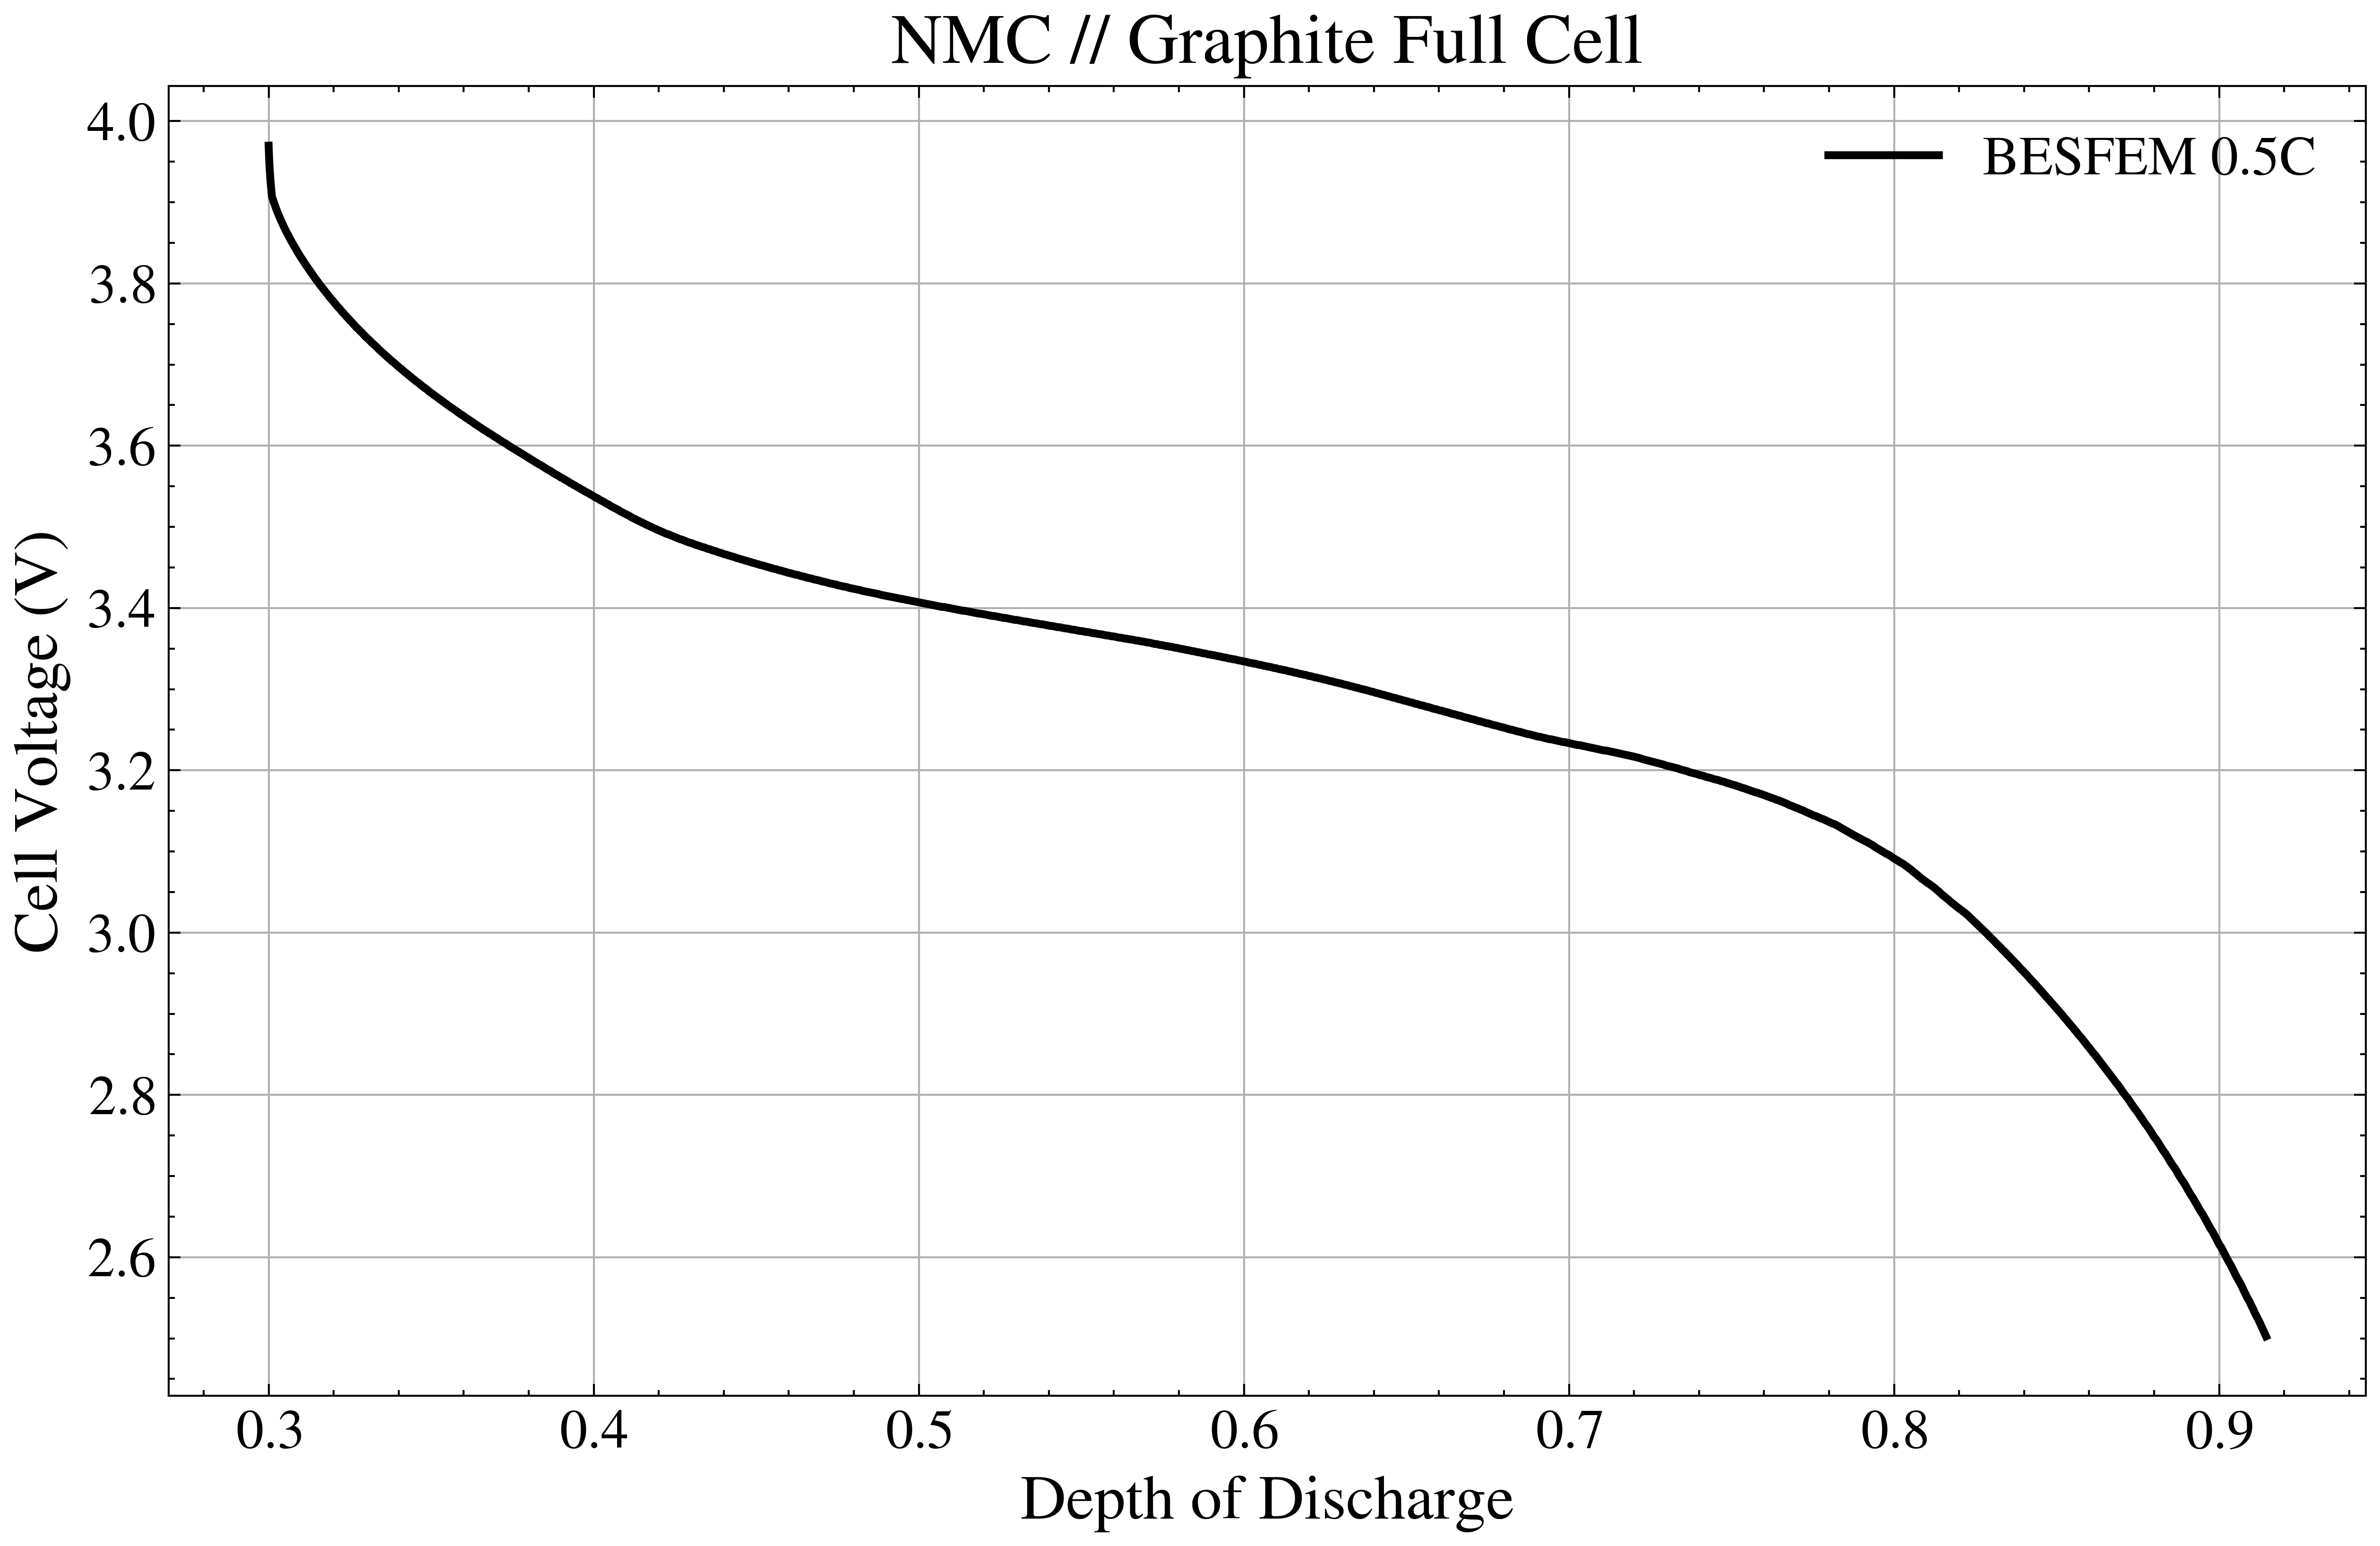

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots

# --- Step 1: Load text file ---
# Replace with your actual file name
file_path = "../bin/full_cell_output.txt"

with open(file_path, 'r') as f:
    lines = f.readlines()

# --- Step 2: Parse each line using regex ---
data = []
pattern = re.compile(
    r"XfrC\s*=\s*([-eE0-9.]+),.*?VCell\s*=\s*([-eE0-9.]+)"
)

for line in lines:
    match = pattern.search(line)
    if match:
        XfrC = float(match.group(1))
        vcell = abs(float(match.group(2)))  # absolute value
        data.append((XfrC, vcell))

# --- Step 3: Convert to DataFrame ---
df = pd.DataFrame(data, columns=["XfrC", "VCell"])

# df = df[df["XfrC"] != 0.3] # Remove timestep 0


# --- Step 4: Plot ---

with plt.style.context(['science', 'ieee', 'no-latex']):
    plt.figure(figsize=(10,6))
    plt.plot(df["XfrC"], df["VCell"], label="BESFEM 3C", linewidth=2)
    # plt.gca().invert_xaxis() # Invert x-axis to show higher XfrC on the left

    plt.xlabel("Depth of Discharge", fontsize=16)
    plt.ylabel("Cell Voltage (V)", fontsize=16)
    plt.title("NMC // Graphite Full Cell", fontsize=18)
    # plt.legend()
    # plt.grid(True)
    plt.tick_params(labelsize=14)

    plt.grid(True)
    plt.legend(fontsize=14)

    plt.show()
    # plt.tight_layout()


In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

def extract_data(file_path):
    """Extract (XfrC, VCell) pairs from a simulation output file."""
    pattern = re.compile(r"XfrC\s*=\s*([-eE0-9.]+),.*?VCell\s*=\s*([-eE0-9.]+)")
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            match = pattern.search(line)
            if match:
                XfrC = float(match.group(1))
                VCell = abs(float(match.group(2)))
                data.append((XfrC, VCell))
    df = pd.DataFrame(data, columns=["XfrC", "VCell"])
    df = df[df["XfrC"] != 0.3]  # remove initial timestep
    return df

# --- File paths ---
file1 = "../bin/3D_full_1C_0.85XfrC.txt"
file2 = "../bin/3D_full_0.5C_0.85XfrC.txt"
file3 = "../bin/3D_full_2C_0.85XfrC.txt"
file4 = "../bin/3D_full_6C_0.85XfrC.txt"

# --- Load both datasets ---
df1 = extract_data(file1)
df2 = extract_data(file2)
df3 = extract_data(file3)
df4 = extract_data(file4)

# --- Plot both ---
plt.figure(figsize=(10,6))
plt.plot(df2["XfrC"], df2["VCell"], label="0.5C", linewidth=2)
plt.plot(df1["XfrC"], df1["VCell"], label="1C", linewidth=2)
plt.plot(df3["XfrC"], df3["VCell"], label="2C", linewidth=2)
plt.plot(df4["XfrC"], df4["VCell"], label="6C", linewidth=2)


plt.xlabel("Cathode Lithiation (XfrC)")
plt.ylabel("Cell Voltage (|VCell|)")
plt.title("Cell Voltage vs Cathode Lithiation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


101 101


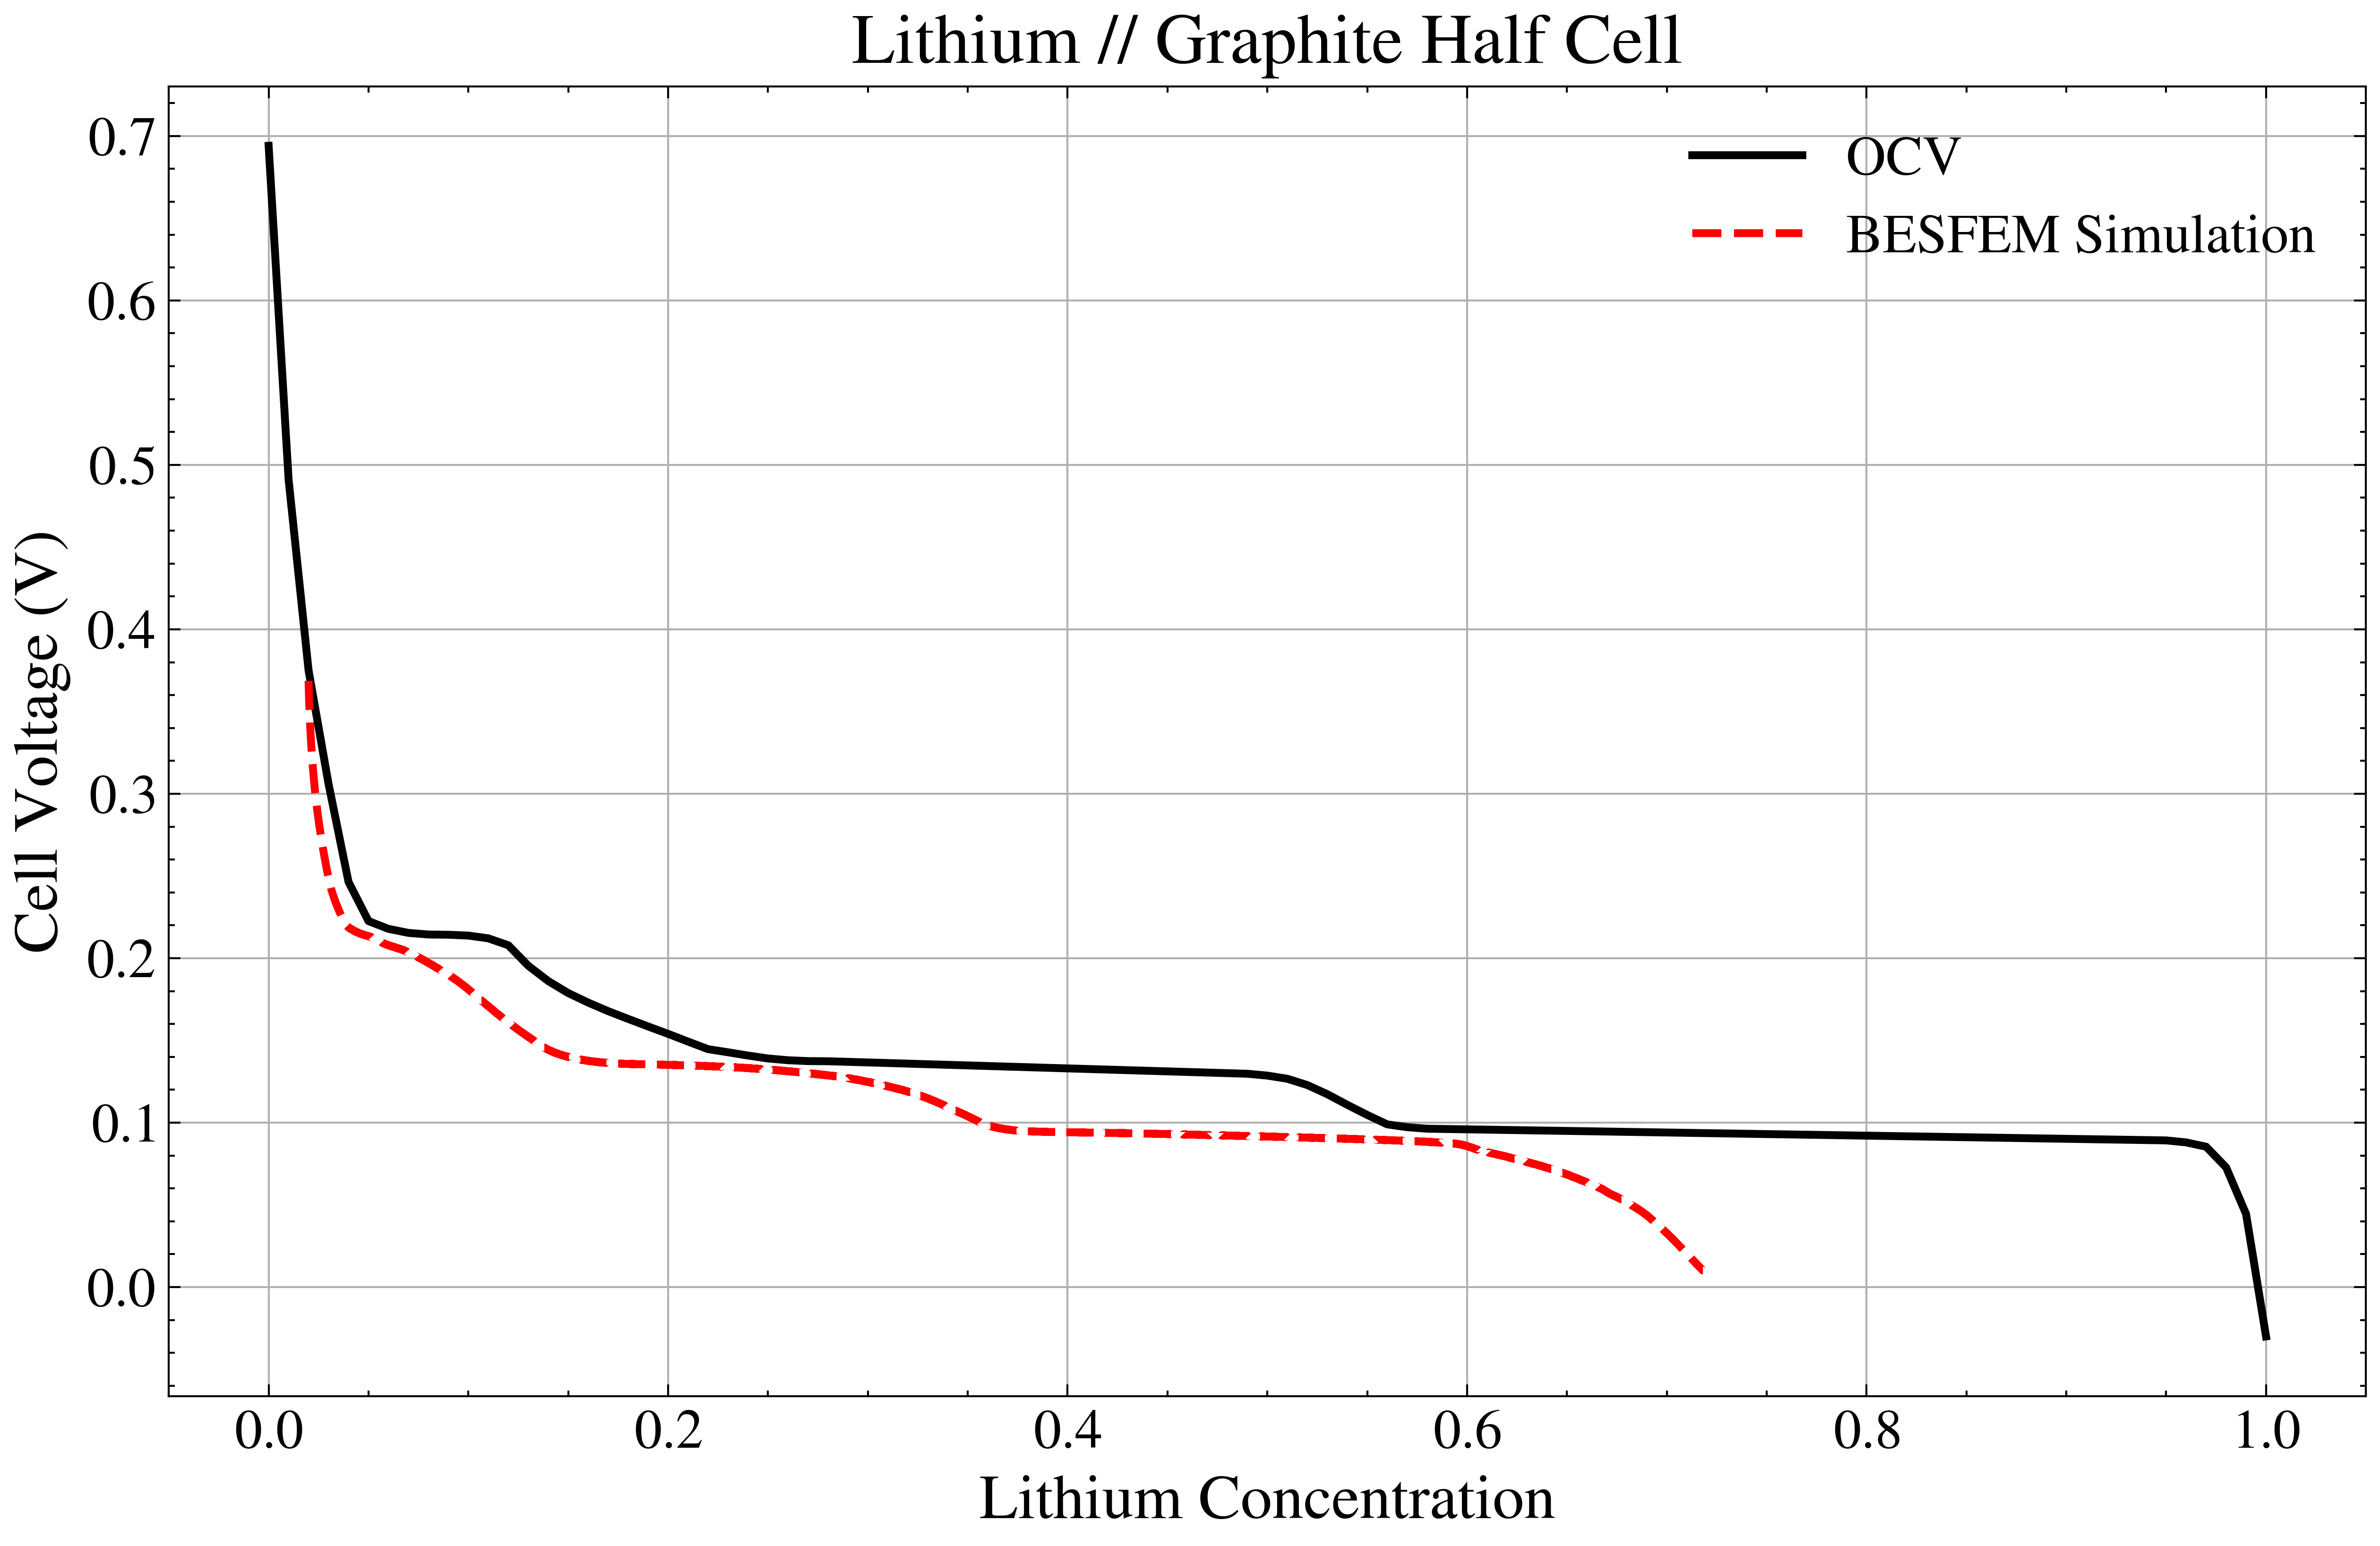

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots

import numpy as np

ocv = np.loadtxt("../inputs/C_Li_O3_101.txt")   # y-axis
x_ocv = np.loadtxt("../inputs/C_Li_X_101.txt")  # x-axis

print(len(x_ocv), len(ocv))


# --- Step 1: Load text file ---
# Replace with your actual file name
file_path = "../bin/half_cell_output.txt"

with open(file_path, 'r') as f:
    lines = f.readlines()

# --- Step 2: Parse each line using regex ---
data = []
pattern = re.compile(
    r"Xfr\s*=\s*([-eE0-9.]+),.*?VCell\s*=\s*([-eE0-9.]+)"
)

for line in lines:
    match = pattern.search(line)
    if match:
        Xfr = float(match.group(1))
        vcell = abs(float(match.group(2)))  # absolute value
        data.append((Xfr, vcell))

# --- Step 3: Convert to DataFrame ---
df = pd.DataFrame(data, columns=["Xfr", "VCell"])

# df = df[df["Xfr"] != 0.3] # Remove timestep 0


# # --- Step 4: Plot ---
# with plt.style.context(['science', 'ieee', 'no-latex']):
#     plt.figure(figsize=(10,6))
#     plt.plot(df["Xfr"], df["VCell"], label="VCell", linewidth=2)
#     # plt.gca().invert_xaxis() # Invert x-axis to show higher XfrA on the left

#     plt.xlabel("Lithium Concentration", fontsize=14)
#     plt.ylabel("Cell Voltage", fontsize=14)
#     plt.title("Lithium // Graphite Half Cell", fontsize=16)
#     # plt.legend()
#     plt.grid(True)
#     # plt.tight_layout()
#     plt.tick_params(axis='both', which='major', labelsize=14)
#     plt.show()

import matplotlib.pyplot as plt

with plt.style.context(['science', 'ieee', 'no-latex']):
    
    fig, ax = plt.subplots(figsize=(10,6))

    # OCV lookup table curve
    ax.plot(x_ocv, ocv,
            label="OCV",
            linewidth=2,
            linestyle="-")

    # BESFEM simulation result
    ax.plot(df["Xfr"], df["VCell"],
            label="BESFEM Simulation",
            linewidth=2,
            linestyle="-")

    # # OCV lookup table curve
    # ax.plot(x_ocv, ocv,
    #         label="OCV",
    #         linewidth=1.5,
    #         linestyle="-")

    ax.set_xlabel("Lithium Concentration", fontsize=16)
    ax.set_ylabel("Cell Voltage (V)", fontsize=16)
    ax.set_title("Lithium // Graphite Half Cell", fontsize=18)

    ax.tick_params(labelsize=14)

    ax.grid(True)
    ax.legend(fontsize=14)

    plt.show()


In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

def extract_data(file_path):
    """Extract (XfrC, VCell) pairs from a simulation output file."""
    pattern = re.compile(r"XfrC\s*=\s*([-eE0-9.]+),.*?VCell\s*=\s*([-eE0-9.]+)")
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            match = pattern.search(line)
            if match:
                XfrC = float(match.group(1))
                VCell = abs(float(match.group(2)))
                data.append((XfrC, VCell))
    df = pd.DataFrame(data, columns=["XfrC", "VCell"])
    df = df[df["XfrC"] != 0.3]  # remove initial timestep
    return df

# --- File paths ---
file1 = "../bin/3D_full_3C_2.5VCell.txt"
file2 = "../bin/3D_full_6C_2.5VCell.txt"

# --- Load both datasets ---
df1 = extract_data(file1)
df2 = extract_data(file2)
# df3 = extract_data(file3)
# df4 = extract_data(file4)

# --- Plot both ---
plt.figure(figsize=(10,6))
plt.plot(df1["XfrC"], df1["VCell"], label="3C", linewidth=2)
plt.plot(df2["XfrC"], df2["VCell"], label="6C", linewidth=2)
# plt.plot(df3["XfrC"], df3["VCell"], label="2C", linewidth=2)
# plt.plot(df4["XfrC"], df4["VCell"], label="6C", linewidth=2)


plt.xlabel("Cathode Lithiation (XfrC)")
plt.ylabel("Cell Voltage (|VCell|)")
plt.title("Cell Voltage vs Cathode Lithiation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
